In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from matplotlib.ticker import MultipleLocator #  controla a escala do eixos
sns.set_style('whitegrid')


In [3]:
df_eda = pd.read_csv('dados_processados.csv')

In [42]:
df_eda.columns

Index(['Date', 'Season', 'Home', 'Away', 'HG', 'AG', 'Res', 'PSCH', 'PSCD',
       'PSCA', 'Date_parsed', 'p_home', 'p_draw', 'p_away', 'dif_prob',
       'goal_diff', 'goal_total', 'bucket_favoritismo', 'home_last5_goals',
       'away_last5_goals', 'home_last5_concede', 'away_last5_concede',
       'home_ewma_5_goals', 'away_ewma_5_goals', 'Res_num',
       'home_last5_winrate', 'away_last5_winrate', 'entropy', 'home_points',
       'away_points', 'away_last5_ppg', 'home_last5_ppg'],
      dtype='str')

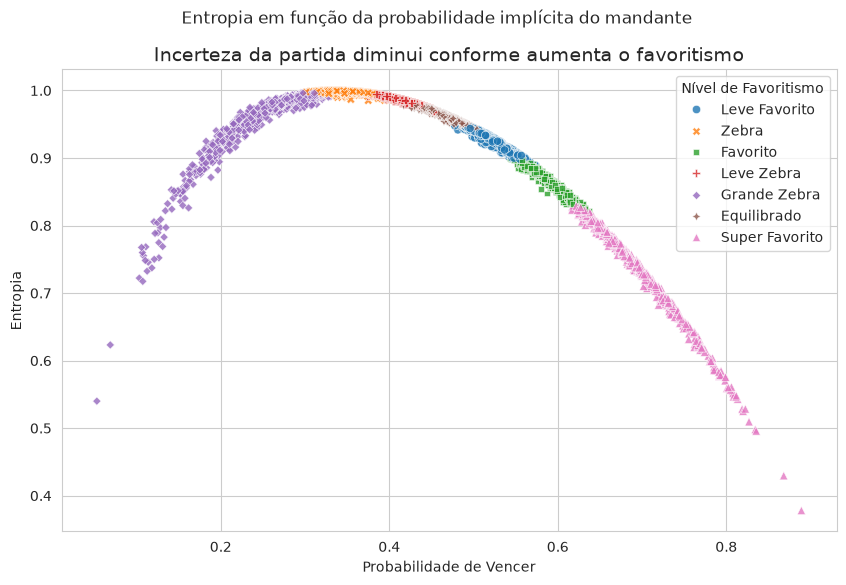

In [40]:
fig, ax = plt.subplots(figsize=(10, 6)) # controla o tamanho do plot
sns.scatterplot(data=df_eda,   x = 'p_home', y = 'entropy', hue = 'bucket_favoritismo', style='bucket_favoritismo', alpha = 0.8)

plt.suptitle('Entropia em função da probabilidade implícita do mandante', fontsize= 12)  # subtitulo do grafico 
plt.title('Incerteza da partida diminui conforme aumenta o favoritismo', fontsize = 14) # titulo do grafico 

plt.xlabel('Probabilidade de Vencer') # nome que vai eixo x 
plt.ylabel('Entropia') # nome que vai no eixo y 
plt.legend(title='Nível de Favoritismo') # altera o titulo da legenda 

plt.show()

Text(0, 0.5, 'Gols')

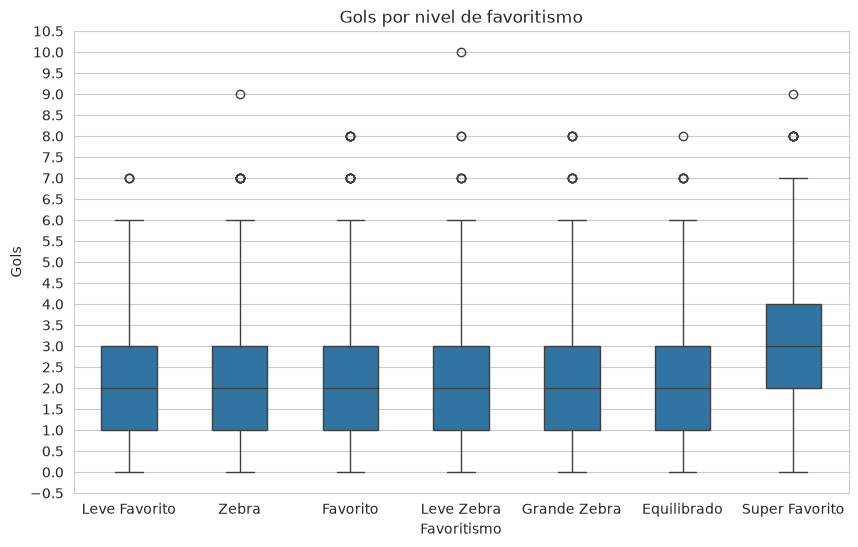

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data = df_eda, x = 'bucket_favoritismo', y = 'goal_total', width= 0.5)

ax.yaxis.set_major_locator(MultipleLocator(0.5))
#ax.set_yticks([0, 1.3, 1.5, 1.75, 2, 2.5, 3, 3.5, 4, 4.5])
plt.title('Gols por nivel de favoritismo')
plt.xlabel('Favoritismo')
plt.ylabel('Gols')

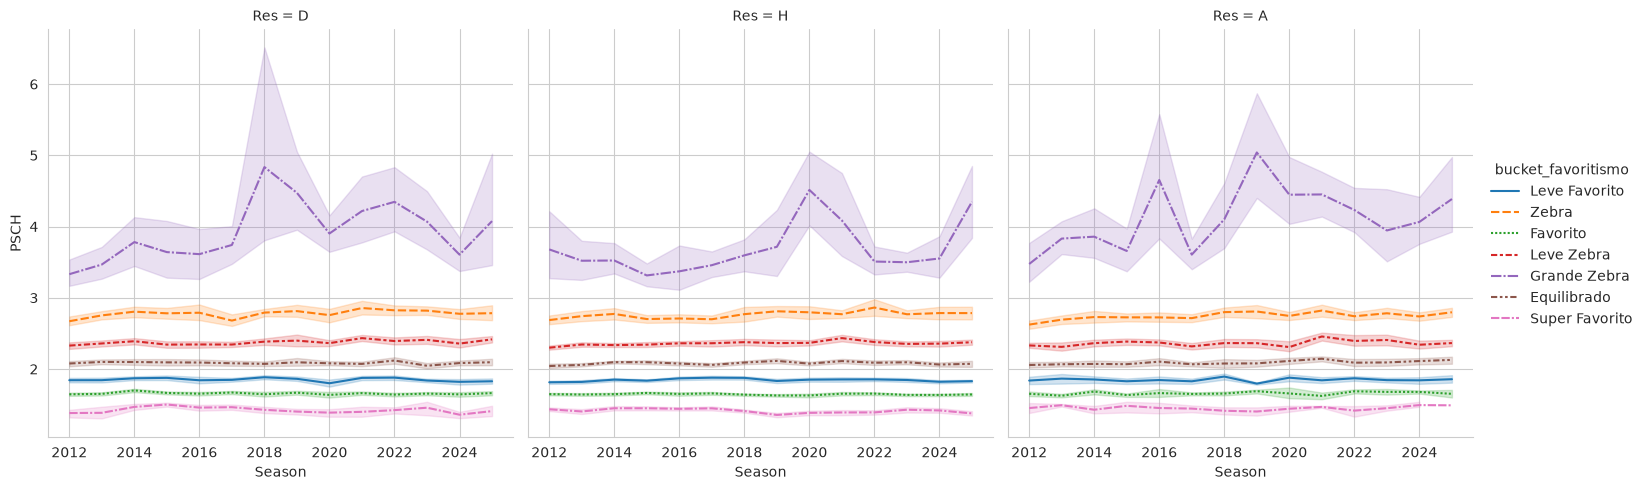

In [85]:

sns.relplot(data = df_eda, kind= 'line', x= 'Season',  y = 'PSCH', 
            col= 'Res',
            hue = 'bucket_favoritismo', # segmenta os dados
            style= 'bucket_favoritismo',
            facet_kws=dict(sharex=False)
            )

<Axes: xlabel='PSCH', ylabel='Density'>

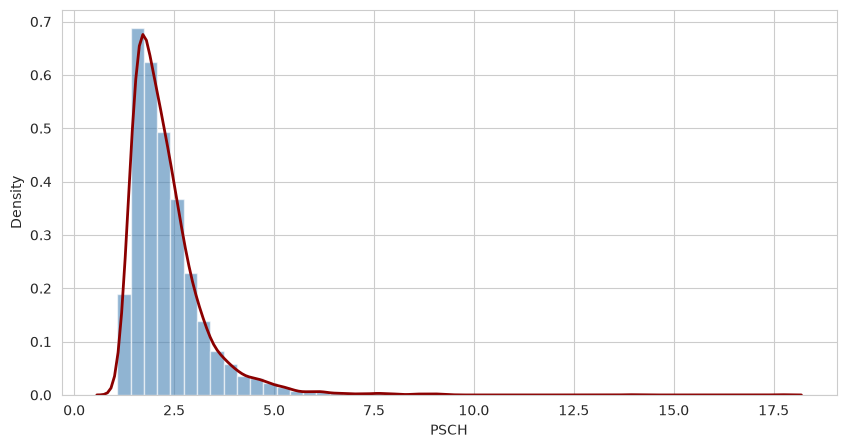

In [ ]:
fig, ax = plt.subplots(figsize =(10,5))

ax.hist(df_eda['PSCH'], bins=50, density=True, alpha=0.6, color='steelblue',
        edgecolor = 'white', label='ODDS casa (PINNACLE)')

sns.kdeplot(df_eda['PSCH'], ax=ax, color='darkred', linewidth=2, label = 'KDE')



In [94]:
odds_melted = pd.melt(
    df_eda[['PSCH', 'PSCD', 'PSCA']],
    value_vars=['PSCH', 'PSCD', 'PSCA'],
    var_name='Tipo de ODD',
    value_name='Valor'
)

#odds_melted

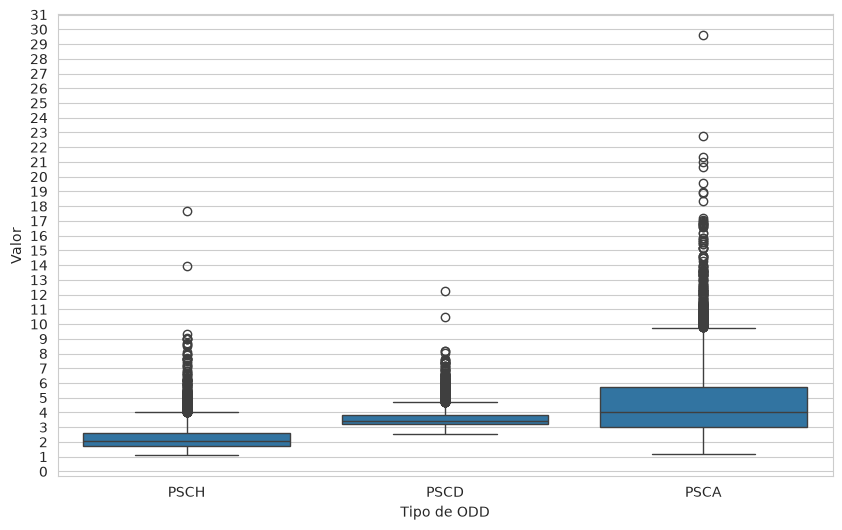

In [98]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data= odds_melted, x='Tipo de ODD', y = 'Valor')
ax.yaxis.set_major_locator(MultipleLocator(1))